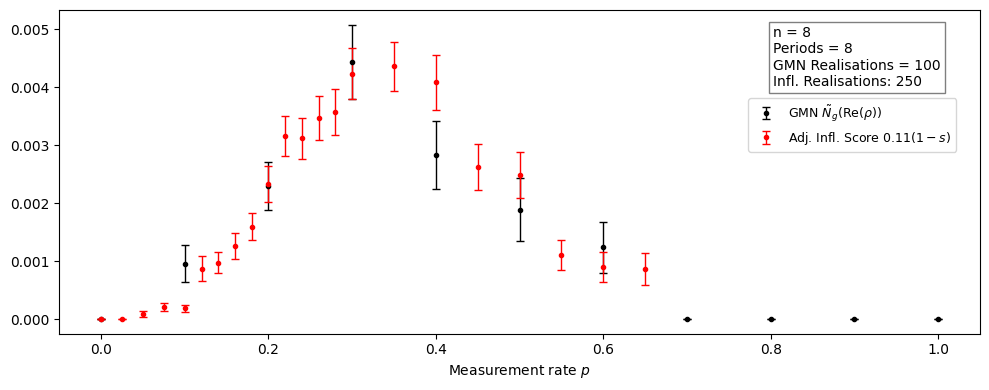

In [12]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# import real GMN data
df = pd.read_csv('gmn_archA_real.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
gmn_values = data_array[1]

# import complex GMN data
df4 = pd.read_csv('gmn_archA_complex.csv')
data_array4 = df4.to_numpy().transpose()
complex_ps = data_array4[0]
complex_gmn_values = data_array4[1]

# import GMN/circuit info
df2 = pd.read_csv('info.csv')
data_array2 = df2.to_numpy().transpose()
n = int(data_array2[0][0])
periods = int(data_array2[1][0])
realizations = int(data_array2[2][0])
res = int(data_array2[3][0])
p_min = float(data_array2[4][0])
p_max = float(data_array2[5][0])

# import inflation data
df3 = pd.read_csv('gnme_n_8_0.0_0.65.csv')
data_array3 = df3.to_numpy().transpose()
infl_ps = data_array3[0]
infl_scores = data_array3[1]

# get means +/- stds for real GMN
ps_unique = list(set(ps))
gmn_means = []
gmn_stds = []
for p in ps_unique:
    gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
    gmn_means.append(np.mean(gmn_values_for_p))
    gmn_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))

# get means +/- stds for complex GMN
complex_ps_unique = list(set(complex_ps))
complex_gmn_means = []
complex_gmn_stds = []
for p in complex_ps_unique:
    complex_gmn_values_for_p = [gmn for gmn, p_val in zip(complex_gmn_values, complex_ps) if p_val == p]
    complex_gmn_means.append(np.mean(complex_gmn_values_for_p))
    complex_gmn_stds.append(np.std(complex_gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))

# get means +/- stds for inflation
infl_reals = 250
infl_ps_unique = list(set(infl_ps))
infl_means = []
infl_stds = []
for p in infl_ps_unique:
    infl_values_for_p = [infl for infl, p_val in zip(infl_scores, infl_ps) if p_val == p]
    infl_means.append(np.mean(infl_values_for_p))
    infl_stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(infl_reals))


# plot GMN
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
# ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

# plot complex GMN
# ax1.errorbar(complex_ps_unique, complex_gmn_means, yerr=complex_gmn_stds, fmt='.', color='blue', ecolor='blue', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\rho)$")


# plot inflation
scale = 0.11
ax1.errorbar(infl_ps_unique, [scale*(1 - m) for m in infl_means], yerr=scale*np.array(infl_stds), 
             fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=f"Adj. Infl. Score ${scale}(1-s)$")


props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nGMN Realisations = {realizations}\nInfl. Realisations: {infl_reals}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

fig.legend(bbox_to_anchor=(0.9675, 0.675), loc="center right", fontsize=9)
fig.tight_layout()

In [ ]:
from mipt import *
import numpy as np

from mipt_rho3_bin_writer import Rho3BinWriter, ring_subsystem_qubits

n = 8
d = 2 * n
ps = np.linspace(0.0, 1.0, 21)
realisations = 1000

subsystem_qubits = ring_subsystem_qubits(n, closed=True)

with Rho3BinWriter(
    "rho3_python_archA.bin",
    total_qubits=n,
    subsystem_qubits=subsystem_qubits,
    periods=d,
    realizations=realisations,
    p_vals=ps,
) as writer:
    for p_index, p in enumerate(ps):
        print(f"Simulating p = {p}...")
        for r in range(realisations):
            rhos = get_mipt_rho_1d(
                n, d, p,
                subsyst=3,
                all_matrices=True,
                closed=True,
            )

            writer.write_record(
                p_index=p_index,
                realization=r,
                p=float(p),
                rhos=rhos,
            )
            print(f"Realisations: {r}/{realisations}", end='\r', flush=True)
        print()

Simulating p = 0.0...
Realisations: 999/1000
Simulating p = 0.05...
Realisations: 999/1000
Simulating p = 0.1...


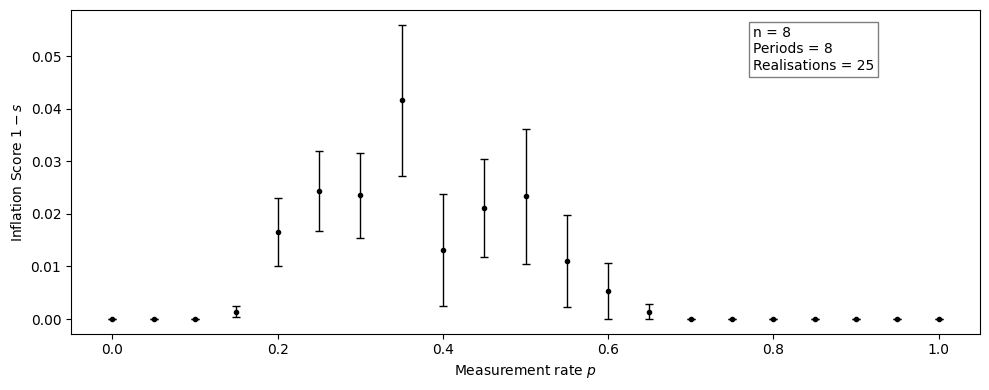

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('runs/gnme/gnme_n_8_real_25.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
infl_values = data_array[1]

# df2 = pd.read_csv('info.csv')
# data_array2 = df2.to_numpy().transpose()

n = 8
periods = 8
realizations = 25


# n = int(data_array2[0][0])
# periods = int(data_array2[1][0])
# realizations = int(data_array2[2][0])
# res = int(data_array2[3][0])
# p_min = float(data_array2[4][0])
# p_max = float(data_array2[5][0])

ps_unique = list(set(ps))
# tmi_means = []
# tmi_stds = []
means = []
stds = []
for p in ps_unique:
    infl_values_for_p = [infl for infl, p_val in zip(infl_values, ps) if p_val == p]
    means.append(np.mean(infl_values_for_p))
    stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(realizations))

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, [1 - m for m in means], yerr=stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'Inflation Score $1 - s$')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.75, 0.95, f"n = {n}\nPeriods = {periods}\nRealisations = {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
 

fig.tight_layout()

In [3]:
import numpy as np
print(np.linspace(0.0, 0.1, 21))

[0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1  ]
